<a href="https://colab.research.google.com/github/kimberlysoto-source/Reconocimiento-de-Patrones-Grupo-/blob/main/Clase3_Challenge2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 2 — Clasificación con k-NN y Naive Bayes</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Pima Indians Diabetes** (NIDDK, 1988), un clásico benchmark biomédico que contiene registros de **768 mujeres** con variables metabólicas y demográficas. La variable objetivo es `Outcome` (0 = no diabética, 1 = diabética con diabetes mellitus tipo 2).

Tu misión: construir, evaluar y comparar un clasificador **k-NN** y un **Naive Bayes Gaussiano** para predecir diabetes a partir de variables clínicas. Para cada decisión de diseño deberás **justificar clínicamente** tu elección.

---
> **Dataset:** `diabetes.csv`  
> **Fuente:** Smith, J.W. et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care.  
> Disponible en: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

---

### Variables del dataset

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Glucosa plasmática en ayunas (OGTT 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue tricipital | mm |
| Insulin | Insulina sérica a las 2h | μU/mL |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Score hereditario de diabetes | — |
| Age | Edad | años |
| **Outcome** | **Diagnóstico de diabetes** | **0/1** |

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — ¿k-NN o Naive Bayes? ¿O ambos?

Para este dataset de variables clínicas continuas, responde **antes de ver los datos**:

1. ¿Qué suposición hace Naive Bayes sobre las features? ¿Es razonable para glucosa, IMC y presión arterial? ¿Por qué?
2. k-NN requiere escalar los datos. Si no lo hicieras, ¿qué feature dominaría la distancia euclidiana y por qué? (pista: revisa las unidades de la tabla)
3. Para un sistema de tamizaje masivo (screening) de diabetes en una posta médica, ¿priorizarías **recall** o **precision**? Argumenta clínicamente.
4. Si la prevalencia de diabetes en la población fuera solo 5% (vs ~35% en este dataset), ¿cómo afectaría eso a la interpretación del posterior de Naive Bayes?

**📝 Tu respuesta (edita esta celda):**
1. Naive Bayes asume que todas las características del paciente son condicionalmente independientes una vez que se conoce la clase (enfermo o sano).Desde un punto de vista clínico, esta suposición no es razonable para variables como la glucosa, el IMC y la presión arterial; debido a que estas variables están fuertemente correlacionadas. No obstante, Naive Bayes, a menudo,logra resultados útiles pese a estos errores técnicos
2. El algoritmo k-NN decide la clase de un paciente midiendo distancias geométricas en el espacio de características. Si no se estandarizan las variables, la glucosa y la presión arterial dominarían completamente la decisión del algoritmo, debido a la magnitud de las unidades. Al calcular la distancia matemática, las diferencias al cuadrado de las variables con valores altos absorberán la distancia total, ignorando por completo cualquier similitud o diferencia que los pacientes tengan en su IMC
3. Para un sistema de tamizaje masivo de diabetes, se debe priorizar categóricamente el Recall (Sensibilidad).En el contexto de un screening, el objetivo principal es captar a la mayor cantidad posible de pacientes en riesgo. Un Falso Negativo (un paciente diabético al que el modelo le dice que está sano) tiene consecuencias clínicas graves, ya que se le privará de un tratamiento temprano. Por el contrario, un Falso Positivo (una falsa alarma) es aceptable en esta fase, ya que el protocolo estándar tras un resultado positivo en tamizaje es simplemente solicitar una segunda prueba más específica y costosa para confirmarlo
4. Naive Bayes decide combinando la probabilidad de los síntomas observados (likelihood) con la probabilidad previa de tener la enfermedad en la población general (prior de clase).Si la prevalencia de la diabetes en la población fuera solo del 5%, el prior estimado para la clase "Diabetes" caería a 0.05, mientras que el prior de "Sano" sería 0.95 . El efecto de esto es que el modelo arrancaría con un fuerte sesgo hacia predecir que los pacientes están sanos, antes incluso de mirar su glucosa o presión. Para que el modelo logre emitir un diagnóstico de diabetes, los valores de las pruebas del paciente tendrían que ser drásticamente altos (una evidencia abrumadora) para poder vencer numéricamente el enorme peso de la probabilidad previa de estar sano.

### 1.2 — Pipeline completo

Dibuja (en texto o diagrama) el pipeline que vas a implementar, indicando **en qué paso** se hace el train/test split y por qué es importante no cruzar esa frontera.

```
diabetes.csv
    │
    ▼
[ Paso A ] Análisis exploratorio de la data para eliminar valores atípicos  ← ¿Qué haces aquí?
    │
    ▼
[ Paso B ] Si, para evitar el data lekage; es decir, que la data usada para test sea usada también para entrenar  ← ¿Aquí ya haces el split? ¿Por qué?
    │
    ├──────── TRAIN ──────────────────────────────────────────────┐
    │                                                             │
    ▼                                                             │
[ Paso C ] Se calculan parámetros estadísticos, media, desviación estándar, para el z-score y la imputación. ← ¿Qué estimas SOLO con train?        │
    │                                                             │
    ▼                                                             │
[ Paso D ] Definimos el número de vecinos para KNN y la métrica de distancia para Naive Bayes  ← Entrenamiento de modelos            │
    │                                                             │
    └──────── TEST ── (aplicas lo estimado en C) ─────────────────┘
    │
    ▼
[ Paso E ] Generar matriz de confusión. Basicamente predecir resultados y compararlos con los reales para observar la capacidad del modelo para detectar la enfermedad  ← Evaluación final
```

**📝 Tu respuesta (edita esta celda):** completa los `___` del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Colores UPCH
UPCH_RED  = '#8B0000'
UPCH_BLUE = '#1565C0'
UPCH_GRAY = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Ruta del dataset
DATA_PATH = 'diabetes.csv'

print('Librerías cargadas correctamente ✓')
#print(DATA_PATH)

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape: (768, 9)

Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum(), "\n")
print(f'\nEstadísticas descriptivas:')
df.describe()
# Se puede observar que valores fisiológicos, como  glucosa BMI, tienen mínimos = 0, hay data inválida

Tipos de datos:


TypeError: bad operand type for unary +: 'str'

### Paso 2.2 — Distribución de clases y desbalance

Distribución de clases:
  No diabética (0): 500 pacientes (65.1%)
  Diabética    (1): 268 pacientes (34.9%)


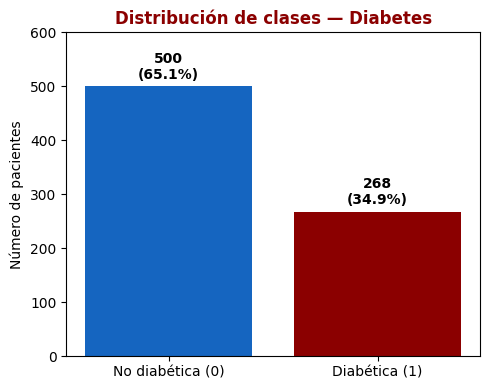

→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula el conteo y porcentaje de cada clase en 'Outcome'
conteo = df['Outcome'].value_counts()
pct    = df['Outcome'].value_counts(normalize=True)*100

print('Distribución de clases:')
print(f'  No diabética (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Diabética    (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))

# TODO 2: grafica las barras con colores [UPCH_BLUE, UPCH_RED]
bars = ax.bar(conteo.index, conteo.values, color=[UPCH_BLUE,UPCH_RED])
ax.set_title('Distribución de clases — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabética (0)', 'Diabética (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico y porcentaje encima de cada barra
labels = [f'{v}\n({p:.1f}%)' for v,p in zip(conteo,pct)]
ax.bar_label(bars,labels=labels,padding=3,fontweight='bold')
ax.set_ylim(0,conteo.max()*1.2)

plt.tight_layout()
plt.savefig('distribucion_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?')
#Claro desbalance, los no diabéticos son casi el doble en número
#que los diabéticos; es posible que el clasificador tenga mejor
#capacidad de detectar a los no diabéticos, solo por tener más data
#de ellos

---
## Ejercicio 3 — Limpieza: valores fisiológicamente imposibles

Este dataset tiene un problema clásico: variables como Glucosa, BloodPressure, BMI e Insulin tienen valores **0** que son fisiológicamente imposibles. Son errores de adquisición codificados como 0 en lugar de `NaN`.

In [ ]:
# Columnas que NO pueden ser 0 fisiológicamente
cols_no_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Valores = 0 por columna (antes de limpiar):')
for col in cols_no_cero:
    n_cero = (df[col] == 0).sum()
    print(f'  {col:<25} {n_cero:>4} ({100*n_cero/len(df):.1f}%)')

Valores = 0 por columna (antes de limpiar):
  Glucose                      5 (0.7%)
  BloodPressure               35 (4.6%)
  SkinThickness              227 (29.6%)
  Insulin                    374 (48.7%)
  BMI                         11 (1.4%)


In [ ]:
df_clean = df.copy()
df_clean[cols_no_cero] = df_clean[cols_no_cero].replace(0,np.nan)
# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores 0 por NaN en todas las columnas de cols_no_cero
# Pista: usa un loop o df_clean[cols_no_cero].replace()
___

print('Valores NaN tras limpieza:')
print(df_clean[cols_no_cero].isnull().sum())
print('\n→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.')

Valores NaN tras limpieza:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.


---
## Ejercicio 4 — EDA: ¿qué features separan mejor las clases?

Antes de entrenar cualquier modelo, exploramos visualmente qué variables tienen más **poder discriminativo**.

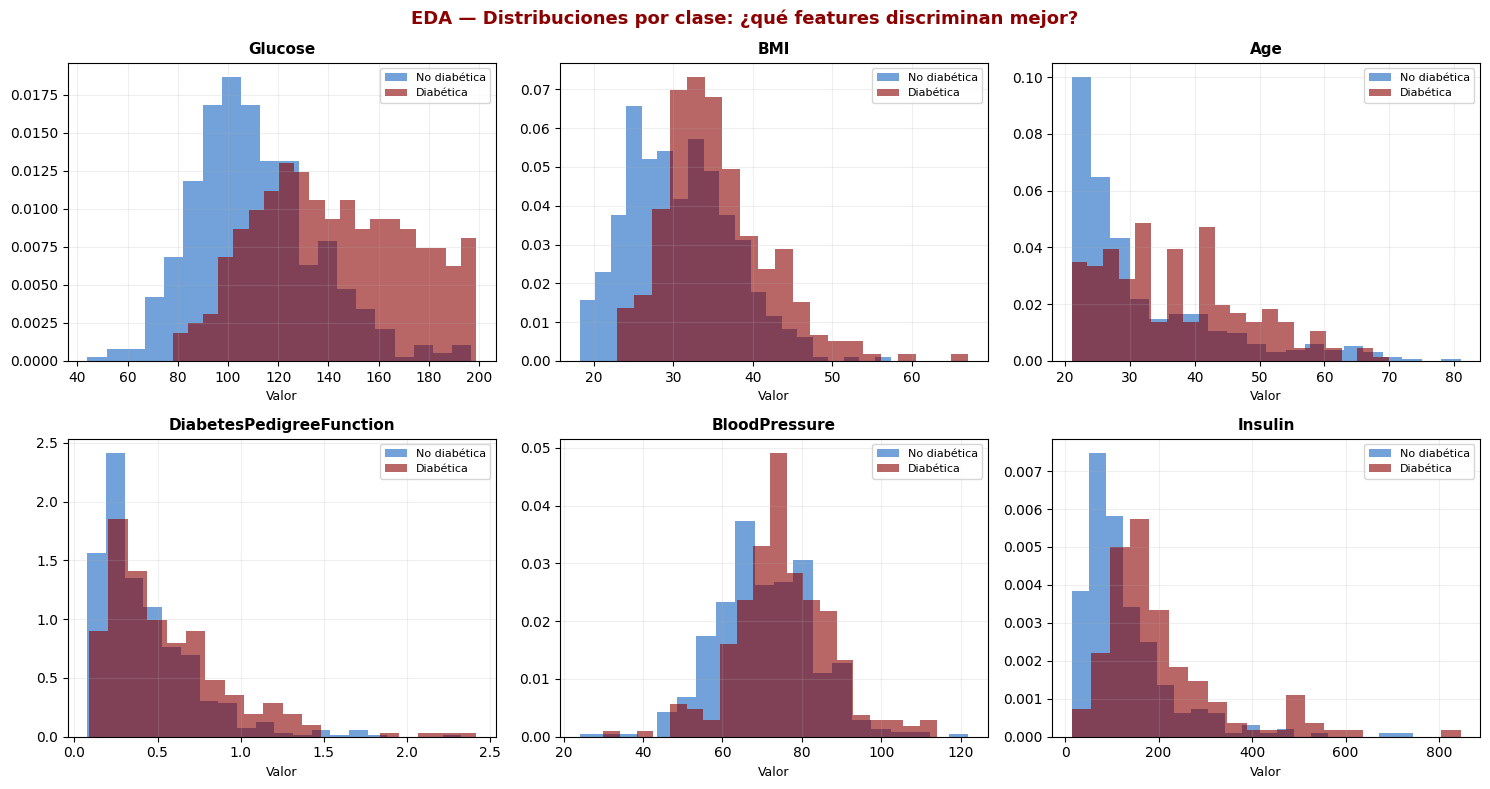

→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?


In [ ]:
features_num = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]
    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos (density=True) para clase 0 y clase 1
    # Usa alpha=0.6, UPCH_BLUE para clase 0, UPCH_RED para clase 1
    # Agrega una línea vertical con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'No diabética'), (1, UPCH_RED, 'Diabética')]:
        valores = df_clean[df_clean['Outcome'] == clase][feat].dropna()
        # TODO: hist y línea de media
        #Histograma
        ax.hist(valores,bins=20,density=True,alpha=0.6,color=color,label = label)
        #Línea media

    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('EDA — Distribuciones por clase: ¿qué features discriminan mejor?',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?')

### Paso 4.2 — Mapa de correlación

Naive Bayes asume independencia condicional. ¿Hay correlaciones fuertes entre features?

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula la matriz de correlación de df_clean (solo features numéricas, sin Outcome)
#       y grafícala con seaborn heatmap. Incluye: cmap='RdBu_r', vmin=-1, vmax=1, annot=True

___

print('→ Identifica los pares de features con |correlación| > 0.5.')
print('  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?')

---
## Ejercicio 5 — Preprocesamiento: split, imputación y escalado

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: separa features (X) y target (y) de df_clean
from sklearn.model_selection import train_test_split
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

# TODO 2: haz train_test_split con test_size=0.2, random_state=42, estratificado
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2 , random_state=42, stratify=y)

print(f'Train: {X_train.shape}  →  {(y_train==1).sum()} diabéticas ({100*(y_train==1).mean():.1f}%)')
print(f'Test:  {X_test.shape}   →  {(y_test==1).sum()} diabéticas ({100*(y_test==1).mean():.1f}%)')

Train: (614, 8)  →  214 diabéticas (34.9%)
Test:  (154, 8)   →  54 diabéticas (35.1%)


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imputa los NaN con la MEDIANA de train (no de todo el dataset)
#       Aplica la mediana de train también al test

mediana_train = X_train.median()
X_train_imp   = X_train.fillna(mediana_train)
X_test_imp    = X_test.fillna(mediana_train)

print(f'NaN en train tras imputación: {np.isnan(X_train_imp).sum()}')
print(f'NaN en test  tras imputación: {np.isnan(X_test_imp).sum()}')

NaN en train tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
NaN en test  tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: escala con StandardScaler
#       - fit_transform sobre X_train_imp
#       - transform (sin fit) sobre X_test_imp

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'Train escalado — media: {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')

Train escalado — media: 0.0000  std: 1.0000


---
## Ejercicio 6 — Entrenamiento de modelos

### Paso 6.1 — Naive Bayes Gaussiano

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con X_train_imp (NB no necesita escalado, usa datos imputados)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
gnb = GaussianNB()
gnb.fit(X_train_imp,y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb = gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7013


### Paso 6.2 — k-NN: selección de k óptimo

Entrena k-NN para **k = 1, 3, 5, 7, 9, 11, 15** usando validación interna sobre train (80/20). Grafica train vs val accuracy y selecciona k óptimo.

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: divide X_train_sc / y_train en subconjuntos train_sub / val (80/20, estratificado)
from sklearn.neighbors import KNeighborsClassifier

X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(X_train_sc,y_train, test_size=0.2 , random_state=42, stratify=y_train)

# TODO 2: itera sobre k_values = [1, 3, 5, 7, 9, 11, 15]
#          guarda acc en train_sub y val para cada k

k_values = [1, 3, 5, 7, 9, 11, 15]
acc_tr_list = []
acc_val_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sub,y_tr_sub)

    acc_tr = knn.score(X_tr_sub, y_tr_sub)
    acc_val = knn.score(X_val, y_val)

    acc_tr_list.append(acc_tr)
    acc_val_list.append(acc_val)

# TODO 3: identifica k óptimo (argmax de acc_val_list)
import numpy as np
indice_max = np.argmax(acc_val_list)
k_optimo = k_values[indice_max]
print(f'k óptimo = {k_optimo}  (val accuracy = {max(acc_val_list):.4f})')

k óptimo = 15  (val accuracy = 0.8211)


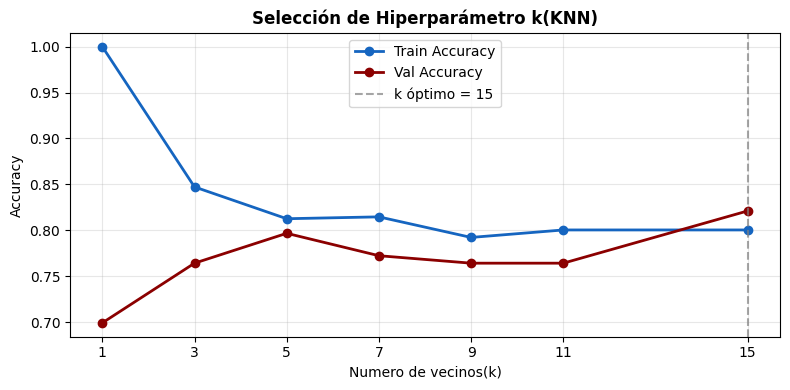

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica train vs val accuracy en función de k
# Incluye: línea vertical en k óptimo, leyenda, títulos, colores UPCH

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, acc_tr_list, marker ="o", label='Train Accuracy', color=UPCH_BLUE, linewidth = 2)
ax.plot(k_values, acc_val_list, marker ="o", label='Val Accuracy', color=UPCH_RED, linewidth = 2)

ax.axvline(x=k_optimo, color='grey', linestyle='--', alpha = 0.7, label=f'k óptimo = {k_optimo}')
ax.set_title("Selección de Hiperparámetro k(KNN)", fontweight = "bold", fontsize = 12)
ax.set_xlabel("Numero de vecinos(k)", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('knn_seleccion_k_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena k-NN final con k_optimo sobre TODO X_train_sc
#       predice sobre X_test_sc
from sklearn.neighbors import KNeighborsClassifier
knn_opt = KNeighborsClassifier(n_neighbors=k_optimo)
knn_opt.fit(X_train_sc,y_train)
y_pred_knn = knn_opt.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'k-NN (k={k_optimo}) — Accuracy final en test: {acc_knn:.4f}')

k-NN (k=15) — Accuracy final en test: 0.7403


---
## Ejercicio 7 — Evaluación clínica

### Paso 7.1 — Matrices de confusión lado a lado

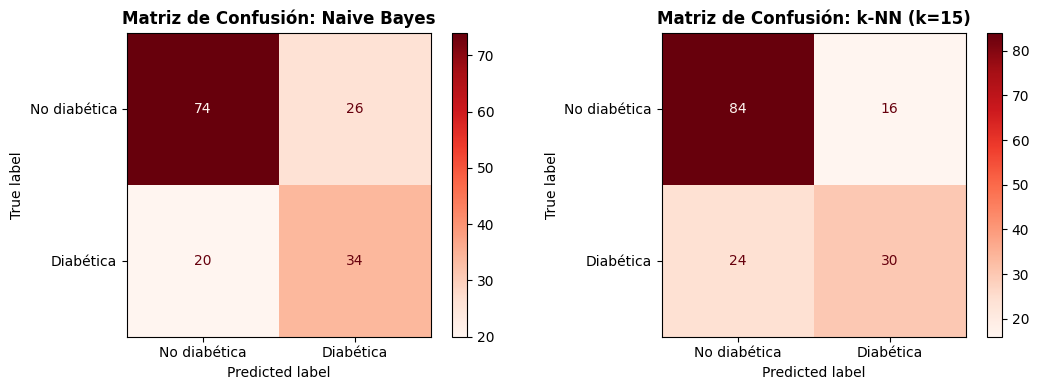

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica las dos matrices de confusión lado a lado (fig con 2 subplots)
# Usa ConfusionMatrixDisplay, cmap='Reds', labels=['No diabética', 'Diabética']
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnb,
    display_labels=['No diabética', 'Diabética'],
    cmap='Reds', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión: Naive Bayes', fontweight='bold')

#Matriz para k-NN
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['No diabética', 'Diabética'],
    cmap='Reds', ax=axes[1]
)
axes[1].set_title(f'Matriz de Confusión: k-NN (k={k_optimo})', fontweight='bold')

plt.tight_layout()
plt.savefig('cm_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 7.2 — Tabla de métricas clínicas

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula para ambos modelos: accuracy, precision, recall, f1
#       sobre la clase positiva (Diabética = 1)
#       imprime una tabla comparativa clara
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
modelos = ['Naive Bayes', f'k-NN (k={k_optimo})']
preds = [y_pred_gnb, y_pred_knn]

data = []
for nombre, y_pred in zip(modelos, preds):
    data.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_metricas = pd.DataFrame(data).set_index('Modelo')
display(df_metricas.round(4))

print('\n→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?')

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Naive Bayes,0.7013,0.5667,0.6296,0.5965
k-NN (k=15),0.7403,0.6522,0.5556,0.6000



→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?


### Paso 7.3 — Gráfico comparativo de métricas

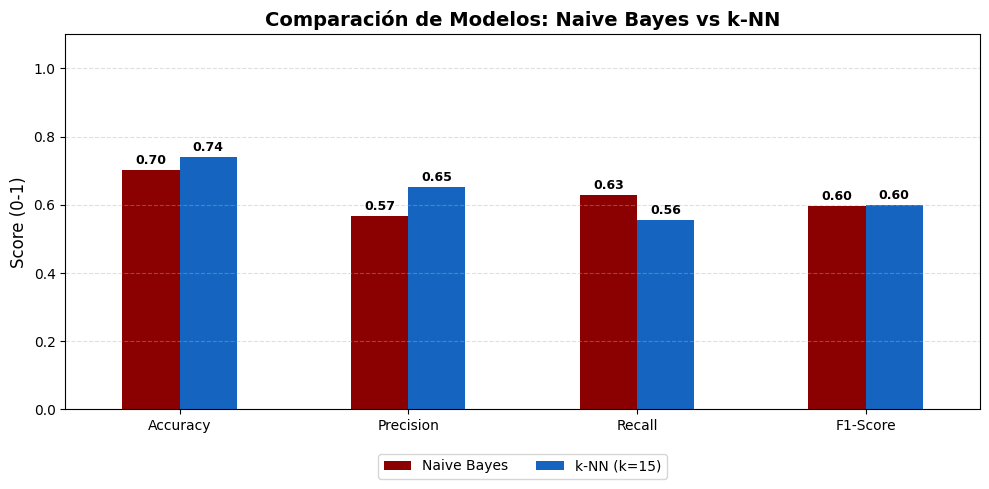

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica un bar chart comparando accuracy, precision, recall y F1
# para k-NN y Naive Bayes, con colores UPCH

df_plot = df_metricas.T

ax = df_plot.plot(kind='bar', figsize=(10, 5), color=[UPCH_RED, UPCH_BLUE], rot=0)


ax.set_title('Comparación de Modelos: Naive Bayes vs k-NN', fontweight='bold', fontsize=14)
ax.set_ylabel('Score (0-1)', fontsize=12)
ax.set_ylim(0, 1.1)  # Espacio extra para las etiquetas
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 8 — Umbral de decisión y probabilidades posteriores

Naive Bayes entrega **probabilidades**, no solo etiquetas. En clínica podemos ajustar el umbral de decisión según el contexto:
- Tamizaje masivo → umbral bajo → maximizar recall (menos FN)
- Confirmación diagnóstica → umbral alto → maximizar precision (menos FP)

Por defecto, scikit-learn usa umbral = 0.5.

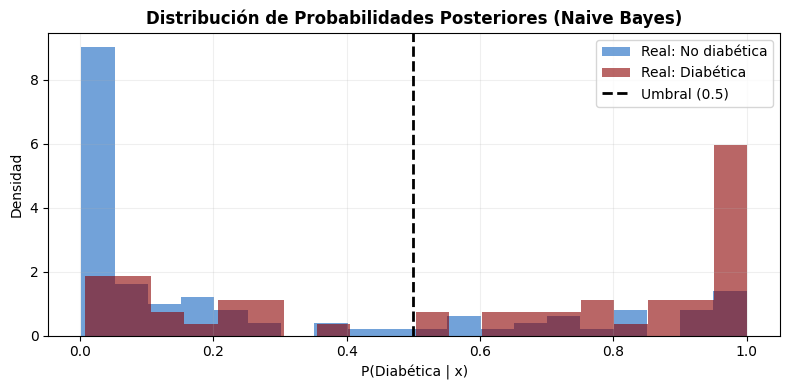

In [ ]:
# Probabilidades posteriores de Naive Bayes
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]  # P(Diabética | x)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: grafica el histograma de probabilidades P(Diabética | x)
#         diferenciando por clase real (y_test == 0 y y_test == 1)
#         con alpha=0.6, UPCH_BLUE y UPCH_RED
#         agrega una línea vertical en 0.5 (umbral por defecto)

fig, ax = plt.subplots(figsize=(8, 4))
proba_clase_0 = proba_gnb[y_test == 0]
proba_clase_1 = proba_gnb[y_test == 1]


ax.hist(proba_clase_0, bins=20, alpha=0.6, color=UPCH_BLUE, label='Real: No diabética', density=True)
ax.hist(proba_clase_1, bins=20, alpha=0.6, color=UPCH_RED, label='Real: Diabética', density=True)


ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral (0.5)')


ax.set_title('Distribución de Probabilidades Posteriores (Naive Bayes)', fontweight='bold')
ax.set_xlabel('P(Diabética | x)', fontsize=10)
ax.set_ylabel('Densidad', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('histograma_proba.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 2: evalúa el modelo con umbral = 0.35 (tamizaje) y umbral = 0.65 (confirmación)
#         Compara recall y precision en ambos casos vs el umbral por defecto (0.5)
#         Imprime una tabla con: umbral, precision, recall, F1
from sklearn.metrics import precision_score, recall_score, f1_score
data_umbrales = []
for umbral in [0.35, 0.50, 0.65]:
    y_pred_umbral = (proba_gnb >= umbral).astype(int)
    data_umbrales.append({
        'Umbral': umbral,
        'Precision': precision_score(y_test, y_pred_umbral),
        'Recall': recall_score(y_test, y_pred_umbral),
        'F1-Score': f1_score(y_test, y_pred_umbral)
    })

# Imprimir tabla comparativa
df_umbrales = pd.DataFrame(data_umbrales).set_index('Umbral')
display(df_umbrales.round(4))

print()
print('→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,')
print('  qué umbral recomendarías y por qué?')
#Recomendaría el umbral de 0.35.
# En comunidades rurales, es vital priorizar el RECALL para no dejar a ningún
# enfermo sin detectar (evitar Falsos Negativos), aunque esto genere algunas
# falsas alarmas que se podrán confirmar con un examen de laboratorio posterior.

,Precision,Recall,F1-Score
Umbral,,,
0.35,0.5385,0.6481,0.5882
0.50,0.5667,0.6296,0.5965
0.65,0.5882,0.5556,0.5714



→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,
  qué umbral recomendarías y por qué?


---
## Ejercicio 9 — Impacto del Prior (reflexión bayesiana)

El Teorema de Bayes que estudiamos en Clase 1 está en el corazón de Naive Bayes. Ahora lo aplicamos directamente.

In [ ]:
# Naive Bayes con prior ajustado manualmente
# Simulamos que estamos en una población con baja prevalencia de diabetes (5%)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con priors=[0.95, 0.05]
#         (usar parámetro priors= en el constructor)
gnb_low_prev = ___

# TODO 2: predice y calcula recall, precision y accuracy en test
y_pred_lp = ___

print('Comparación de priors:')
print(f'  Prior original (~35% diabetes):  Recall={recall_score(y_test, y_pred_gnb):.4f}  Precision={precision_score(y_test, y_pred_gnb):.4f}')
print(f'  Prior 5% diabetes:               Recall={recall_score(y_test, y_pred_lp):.4f}  Precision={precision_score(y_test, y_pred_lp):.4f}')
print()
print('📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?')
print('   Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).')

---
## Ejercicio 10 — Análisis final e interpretación clínica

Responde las siguientes preguntas integrando los resultados obtenidos:

### 10.1 — ¿Cuál modelo elegirías y para qué escenario?

Completa la tabla:

| Escenario | Modelo recomendado | Métrica prioritaria | Justificación |
|---|---|---|---|
| Screening masivo en posta rural | ___ | ___ | ___ |
| Confirmación diagnóstica en hospital | ___ | ___ | ___ |
| Sistema embebido en glucómetro portátil | ___ | ___ | ___ |

**📝 Tu respuesta (edita esta celda)**

### 10.2 — Limitaciones del análisis

1. ¿Qué asunciones de Naive Bayes se violan en este dataset? ¿Cómo lo detectaste?
2. ¿Por qué k-NN puede ser problemático si el dataset tuviera 50,000 pacientes y 200 features?
3. ¿Qué otra métrica de evaluación sería importante reportar en el contexto clínico?

**📝 Tu respuesta (edita esta celda):**
1. ___
2. ___
3. ___

In [ ]:
# Resumen ejecutivo final
print('=' * 60)
print('          RESUMEN DEL CHALLENGE 2')
print('=' * 60)
print(f'Dataset: Pima Indians Diabetes  (N={len(df)}, d=8)')
print(f'Prevalencia en test: {100*(y_test==1).mean():.1f}%')
print()
print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 60)

for nombre, y_p in [(f'k-NN (k={k_optimo})', y_pred_knn), ('Naive Bayes', y_pred_gnb)]:
    print(f'{nombre:<20} '
          f'{accuracy_score(y_test, y_p):.4f}       '
          f'{recall_score(y_test, y_p):.4f}       '
          f'{precision_score(y_test, y_p):.4f}       '
          f'{f1_score(y_test, y_p):.4f}')

print()
print('Archivos generados:')
print('  distribucion_diabetes.png   eda_diabetes.png')
print('  knn_seleccion_k_diabetes.png cm_comparacion.png')
print('  comparacion_metricas.png    histograma_proba.png')